## Train Model

定義並訓練 LSTM 雙輸入模型，分別評估驗證集與測試集的表現。

In [ ]:
import numpy as np
import pdb
import pandas as pd
import matplotlib.pyplot as plt
import glob
import sys
import pickle
from sklearn.metrics import confusion_matrix
from sklearn.metrics import auc

from keras.models import Sequential
from keras.layers import LSTM
from keras.layers import Dense
from keras.regularizers import l2
from keras.layers import TimeDistributed, Bidirectional, BatchNormalization, Dropout, Input, Add, Masking
from keras import Model
from keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from keras.models import load_model
from keras.callbacks import ModelCheckpoint

In [ ]:
import os
os.makedirs('./plots', exist_ok=True)
print('plots 資料夾建立完成')

plots 資料夾建立完成


In [ ]:
# 計算 ROC 曲線與 AUC，並找出最佳門檻值
def roc(predictions, true, filename):
    predictions = predictions.flatten()
    true = true.flatten()

    # 在預測機率範圍內均勻取 50 個門檻值
    thresh_vals = np.linspace(np.min(predictions), np.max(predictions), 50)
    results = []

    # 用每個門檻值計算 TPR、FPR 和準確率
    for thresh in thresh_vals:
        # 預測機率 > 門檻 → 1（敗血症），否則 → 0（正常）
        tmp_predictions = (predictions > thresh).astype(int)
        tn, fp, fn, tp = confusion_matrix(true, tmp_predictions).ravel()
        tpr = tp/(tp+fn)          # 真陽性率（敗血症猜對的比例）
        fpr = fp/(tn+fp)          # 假陽性率（正常被誤判的比例）
        acc = (tp+tn)/(tn+fp+fn+tp)  # 整體準確率

        tmp_dict = {'acc': acc, 'tpr': tpr, 'fpr': fpr, 'thresh': thresh}
        results.append(tmp_dict)

    # 依門檻值由高到低排序
    results = pd.DataFrame(results)
    results = results.sort_values(by='thresh', ascending=False)

    # 計算 AUC 並畫出 ROC 曲線
    AUC = auc(results['fpr'].values, results['tpr'].values)

    plt.figure(figsize=(10,6))
    plt.plot(results['fpr'], results['tpr'], '*-')
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.title('ROC\nAUC=%.2f' % AUC)
    plt.tight_layout()
    plt.savefig('plots/ROC_%s.png' % filename, dpi=250)
    plt.show()

    # 找出準確率最高時對應的最佳門檻值
    results = results.sort_values(by='acc', ascending=False)
    final_thresh = results.head(1)['thresh'].values[0]

    return results, final_thresh


In [ ]:
# 載入訓練資料
train = pd.read_pickle('train.pkl').reset_index(drop=True)

# 隨機打亂後切割：80% 訓練集，20% 驗證集
N = len(train)
train = train.sample(frac=1).reset_index(drop=True)
val = train[:int(N*0.2)]
train = train[int(N*0.2):]

# 處理訓練集
# LSTM 輸入格式：(筆數, 序列長度, 特徵數)
y_train = np.asarray(list(train['label']))
y_train = to_categorical(y_train)                         # 轉成 one-hot 編碼
X_train_cont = np.asarray(list(train['X_cont'].values))   # 連續時序特徵（10×5）
X_train_cat = train.drop(['X_cont', 'label'], axis=1)     # 類別特徵（33個欄位）

# NaN 換成 π，供 Masking 層識別並忽略
X_train_cat[X_train_cat.isna()] = np.pi
X_train_cat = np.asarray(list(X_train_cat.values))

# 處理驗證集（同訓練集流程）
y_val = np.asarray(list(val['label']))
y_val = to_categorical(y_val)
X_val_cont = np.asarray(list(val['X_cont'].values))
X_val_cat = val.drop(['X_cont', 'label'], axis=1)
X_val_cat[X_val_cat.isna()] = np.pi
X_val_cat = np.asarray(list(X_val_cat.values))

# 載入並處理測試集（同訓練集流程）
test = pd.read_pickle('test.pkl')
y_test = np.asarray(list(test['label']))
y_test = to_categorical(y_test)
X_test_cont = np.asarray(list(test['X_cont'].values))
X_test_cat = test.drop(['X_cont', 'label'], axis=1)
X_test_cat[X_test_cat.isna()] = np.pi
X_test_cat = np.asarray(list(X_test_cat.values))

### 模型架構
- 模型1：雙向 LSTM（處理 HR, MAP, O2Sat, SBP, Resp 的 10 小時時序資料）
- 模型2：Dense 層（處理 33 個類別特徵，缺失值以 π 遮蔽）
- 合併方式：Add()（逐元素相加）
- 輸出：softmax（正常/敗血症機率）

### 訓練設定
| 項目 | 數值 |
|------|------|
| Batch Size | 64 |
| 最大輪數 | 50 |
| Early Stopping | patience=5 |
| 優化器 | Adam |
| 損失函數 | Categorical Crossentropy

In [ ]:
BATCH_SIZE = 64             # 每次訓練的批次大小
INPUT_SEQ_LEN_MODEL1 = 10   # 模型1輸入序列長度（10小時視窗）
INPUT_NUM_CH_MODEL1 = 5     # 模型1輸入特徵數（HR, MAP, O2Sat, SBP, Resp）
INPUT_FEATS_MODEL2 = 33     # 模型2輸入特徵數（cols_to_bin 欄位數量）

In [ ]:
# 計算類別權重（敗血症病人遠少於正常病人）
count_class_0 = np.sum(y_train[:,1].astype(int)==0)   # 正常筆數
count_class_1 = np.sum(y_train[:,1].astype(int)==1)   # 敗血症筆數
max_class_counts = np.max((count_class_0, count_class_1)) # 取較大的類別數

# 數量少的類別給予較高權重，讓模型重視少數類別
class_weights = {0: max_class_counts/count_class_0, 1: max_class_counts/count_class_1}
print('class weights -- no sepsis: {}, sepsis: {}'.format(class_weights[0], class_weights[1]))

class weights -- no sepsis: 1.0, sepsis: 53.45896699137992


In [ ]:
# 模型1：處理連續時序特徵（HR, MAP, O2Sat, SBP, Resp）
input1 = Input(shape=(INPUT_SEQ_LEN_MODEL1, INPUT_NUM_CH_MODEL1))  # 輸入形狀 (10, 5)
# 第一層雙向 LSTM：輸出每個時間步供下一層使用
model1 = Bidirectional(LSTM(100, kernel_regularizer=l2(0.001), return_sequences=True))(input1)
# 第二層雙向 LSTM：壓縮時序資訊為單一向量
model1 = Bidirectional(LSTM(75, kernel_regularizer=l2(0.001)))(model1)
# 全連接層逐步壓縮特徵（35 → 15）
model1 = Dense(35, kernel_regularizer=l2(0.001), activation='relu')(model1)
model1 = BatchNormalization()(model1)  # 正規化加速訓練
model1 = Dense(15, kernel_regularizer=l2(0.001), activation='relu')(model1)
model1 = BatchNormalization()(model1)

# 模型2：處理類別特徵（33個欄位，缺失值多）
input2 = Input(shape=(INPUT_FEATS_MODEL2,))  # 輸入形狀 (33,)
model2 = Masking(mask_value=np.pi)(input2)   # 遇到 π 的位置跳過不計算
model2 = Dense(30, kernel_regularizer=l2(0.001), activation='relu')(model2)
model2 = BatchNormalization()(model2)
model2 = Dense(15, kernel_regularizer=l2(0.001), activation='relu')(model2)
model2 = BatchNormalization()(model2)

# 合併兩個模型的輸出（相加）
model_add = Add()([model1, model2])

# 輸出層：2個節點（正常/敗血症的機率），softmax 確保機率加總為 1
output = Dense(2, kernel_regularizer=l2(0.001), activation='softmax')(model_add)

# 組合模型並編譯
model = Model(inputs=[input1, input2], outputs=output)
model.compile(loss='categorical_crossentropy', optimizer='adam')
print(model.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 10, 5)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 10, 200)   │     84,800 │ input_layer[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 33)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 150)       │    165,600 │ bidirectional[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, 33)        │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 33)        │          0 │ input_layer_1[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 35)        │      5,285 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 30)        │      1,020 │ masking[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None)            │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 35)        │        140 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30)        │        120 │ dense_2[0][0],    │
│ (BatchNormalizatio… │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 15)        │        540 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 15)        │        465 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 15)        │         60 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 15)        │         60 │ dense_3[0][0],    │
│ (BatchNormalizatio… │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 15)        │          0 │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 2)         │         32 │ add[0][0]         │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 258,122 (1008.29 KB)

 Trainable params: 257,932 (1007.55 KB)

 Non-trainable params: 190 (760.00 B)

None


In [ ]:
# 訓練模型（最多 50 輪，連續 5 輪 val_loss 未改善則提早停止）
# ModelCheckpoint 自動儲存 val_loss 最低的模型到 model.h5
checkpoint = ModelCheckpoint('model.keras', monitor='val_loss', verbose=1, save_best_only=True, mode='auto', save_freq='epoch')
earlystop = EarlyStopping(monitor='val_loss', min_delta=0, patience=5)

history = model.fit(
    [X_train_cont, X_train_cat],
    y_train,
    batch_size=BATCH_SIZE,
    epochs=50,
    validation_data=([X_val_cont, X_val_cat], y_val),
    callbacks=[earlystop, checkpoint],  # 提早停止 + 儲存最佳模型
    class_weight=class_weights,          # 處理資料不平衡
    verbose=1
)

# 儲存訓練歷史記錄，供後續畫訓練曲線使用
pickle.dump(history, open('history.pkl', 'wb'))

Epoch 1/50
12142/12142 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 1.4132
Epoch 1: val_loss improved from None to 0.58820, saving model to model.keras

Epoch 1: finished saving model to model.keras
12142/12142 ━━━━━━━━━━━━━━━━━━━━ 801s 65ms/step - loss: 1.2861 - val_loss: 0.5882
Epoch 2/50
12142/12142 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 1.2147
Epoch 2: val_loss did not improve from 0.58820
12142/12142 ━━━━━━━━━━━━━━━━━━━━ 814s 67ms/step - loss: 1.1985 - val_loss: 0.6569
Epoch 3/50
12142/12142 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 1.1769
Epoch 3: val_loss did not improve from 0.58820
12142/12142 ━━━━━━━━━━━━━━━━━━━━ 862s 67ms/step - loss: 1.1676 - val_loss: 0.9649
Epoch 4/50
12141/12142 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 1.1635
Epoch 4: val_loss did not improve from 0.58820
12142/12142 ━━━━━━━━━━━━━━━━━━━━ 808s 67ms/step - loss: 1.1593 - val_loss: 0.7720
Epoch 5/50
12141/12142 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 1.1442
Epoch 5: val_loss improved from 0.58820 to 0.51

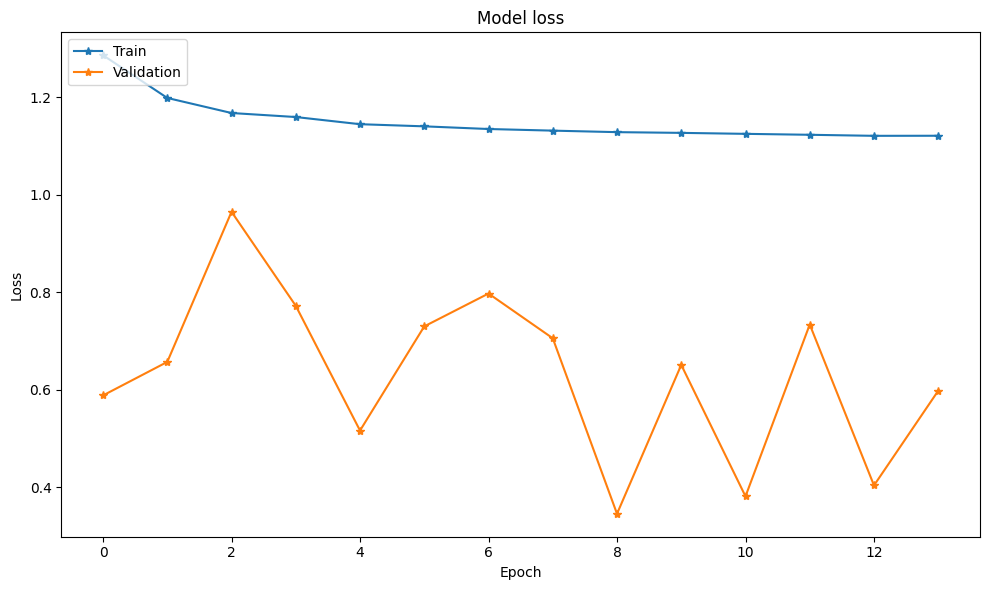

In [ ]:
# 畫出訓練集 vs 驗證集的損失值變化曲線
plt.figure(figsize=(10,6))
plt.plot(history.history['loss'], '*-')      # 訓練集 loss
plt.plot(history.history['val_loss'], '*-')  # 驗證集 loss
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.tight_layout()
plt.savefig('plots/loss.png', dpi=250)
plt.show()
plt.close()

6071/6071 ━━━━━━━━━━━━━━━━━━━━ 77s 13ms/step


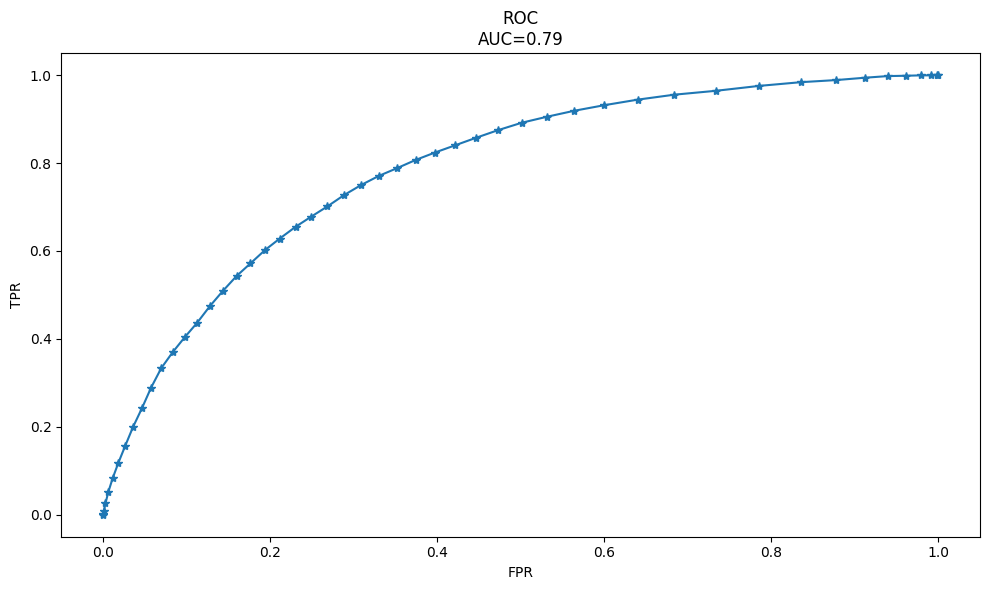

In [ ]:
# 對驗證集預測並計算 ROC 曲線與最佳門檻值
predictions = model.predict([X_val_cont, X_val_cat])
# predictions[:,1] → 敗血症機率，y_val[:,1] → 實際標籤
results_df, thresh_final = roc(predictions[:,1].flatten()
                               , y_val[:,1].flatten(),
                               'val')

results_df = results_df.sort_values(by='fpr')# 依 FPR 排序

5248/5248 ━━━━━━━━━━━━━━━━━━━━ 65s 12ms/step


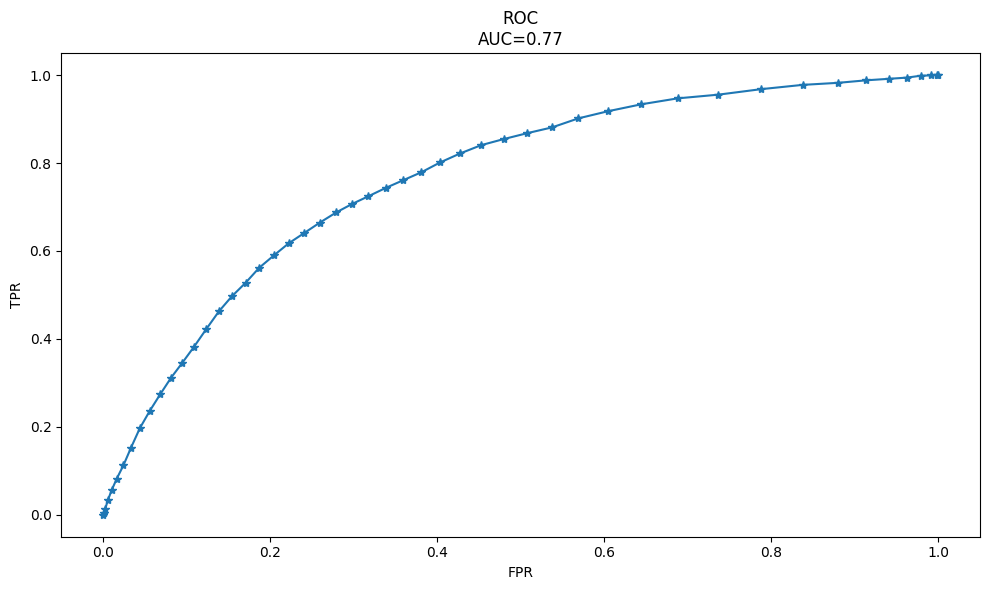

In [ ]:
# 對測試集預測並計算 ROC 曲線與最佳門檻值
# 測試集是模型從未看過的資料，代表最終真實表現
predictions = model.predict([X_test_cont, X_test_cat])
results_df, thresh_final = roc(predictions[:,1].flatten(), y_test[:,1].flatten(), 'test')
results_df = results_df.sort_values(by='fpr')  # 依 FPR 排序供繪圖用

### 評估結果
| 資料集 | AUC |
|--------|-----|
| 驗證集 | 0.79 |
| 測試集 | 0.77 |